In [ ]:
import marimo as mo

# cloudposterior: Parallel model comparison

`cp.map` fits **many models at once** on the cloud -- the canonical parallel
Bayesian workflow. Here we fit three increasingly-pooled radon models
concurrently and compare them with LOO cross-validation.

> Run this notebook locally (Jupyter or marimo). `cp.map` prints job-level
> progress inline and serves a live dashboard for the per-model detail.

In [ ]:
import arviz as az
import pandas as pd
import pymc as pm

## Start fresh

Clear any cached fits and this project's Modal volume so the notebook runs
cold and reproducibly. (Shown in marimo; hidden in the rendered notebook.)

In [ ]:
import shutil
from pathlib import Path

import cloudposterior as cp

# Wipe the local result cache + this project's Modal volume so the example
# starts cold. The cp.map cells below use `cp`, so marimo runs this first.
shutil.rmtree(Path(".cloudposterior"), ignore_errors=True)
cp.cleanup_volumes()

/Users/spencerboucher/Projects/cloudposterior-map-dashboard/cloudposterior/backends/modal_backend.py:790: AsyncUsageWarning: A blocking Modal interface is being used in an async context.

This may cause performance issues or bugs. Consider rewriting to use Modal's async interfaces:
https://modal.com/docs/guide/async

Suggested rewrite:
  await modal.Volume.objects.delete.aio(volume_name)

Original line:
  modal.Volume.objects.delete(volume_name)


## Data

919 household radon measurements across 85 Minnesota counties (Gelman & Hill, 2006).

In [ ]:
df = pd.read_csv(pm.get_data("radon.csv"))
counties = df.county.unique()
county_idx = df.county_code.values
log_radon = df.log_radon.values
floor = df.floor.values

## Three models

- **Complete pooling** -- one intercept for all counties (ignores county).
- **Hierarchical** -- partial pooling: county intercepts shrink toward a shared mean.
- **Unpooled** -- an independent intercept per county (no sharing).

All three share a floor (basement vs first-floor) fixed effect. We build them
in one cell so each name is defined once (marimo's single-definition rule).

In [ ]:
with pm.Model(name="pooled") as pooled:
    a = pm.Normal("a", 0, 5)
    b = pm.Normal("b_floor", 0, 5)
    sigma = pm.HalfNormal("sigma", 2)
    pm.Normal("obs", a + b * floor, sigma, observed=log_radon)

with pm.Model(name="hierarchical", coords={"county": counties}) as hierarchical:
    mu_a = pm.Normal("mu_a", 0, 5)
    sigma_a = pm.HalfNormal("sigma_a", 2)
    a_raw = pm.Normal("a_raw", 0, 1, dims="county")
    a = pm.Deterministic("a", mu_a + sigma_a * a_raw, dims="county")
    b = pm.Normal("b_floor", 0, 5)
    sigma = pm.HalfNormal("sigma", 2)
    pm.Normal("obs", a[county_idx] + b * floor, sigma, observed=log_radon)

with pm.Model(name="unpooled", coords={"county": counties}) as unpooled:
    a = pm.Normal("a", 0, 5, dims="county")
    b = pm.Normal("b_floor", 0, 5)
    sigma = pm.HalfNormal("sigma", 2)
    pm.Normal("obs", a[county_idx] + b * floor, sigma, observed=log_radon)

models = [pooled, hierarchical, unpooled]

## Fit all three in parallel

`cp.map` uploads each model once and runs the fits concurrently on the cloud.
Results come back in input order.

It also serves a **live dashboard** by default (printed as a link below): an
overview of all three models that you can drill into for any single model's
chains, convergence, and live traces -- with a global *Stop all* and a
per-model *Stop*. Pass `dashboard=False` to opt out.

In [ ]:
idatas = cp.map(models, {"draws": 1000, "tune": 1000, "chains": 4})

cp.map: fitting 3 model(s) in parallel ...
cp.map: dashboard: https://justmytwospence--pooled-ba0fd9-dev.modal.run
cp.map: [1/3] done
cp.map: [2/3] done
cp.map: [3/3] done


Dashboard: https://justmytwospence--pooled-ba0fd9-dev.modal.run/ <?xml version='1.0' encoding='UTF-8'?>
 <path d="M2.4,2.4H3V3H2.4zM3,2.4H3.6V3H3zM3.6,2.4H4.2V3H3.6zM4.2,2.4H4.8V3H4.2zM4.8,2.4H5.4V3H4.8zM5.4,2.4H6V3H5.4zM6,2.4H6.6V3H6zM8.4,2.4H9V3H8.4zM9.6,2.4H10.2V3H9.6zM12,2.4H12.6V3H12zM12.6,2.4H13.2V3H12.6zM13.2,2.4H13.8V3H13.2zM13.8,2.4H14.4V3H13.8zM14.4,2.4H15V3H14.4zM15.6,2.4H16.2V3H15.6zM16.2,2.4H16.8V3H16.2zM18,2.4H18.6V3H18zM18.6,2.4H19.2V3H18.6zM19.2,2.4H19.8V3H19.2zM19.8,2.4H20.4V3H19.8zM20.4,2.4H21V3H20.4zM21,2.4H21.6V3H21zM21.6,2.4H22.2V3H21.6zM2.4,3H3V3.6H2.4zM6,3H6.6V3.6H6zM7.8,3H8.4V3.6H7.8zM9,3H9.6V3.6H9zM11.4,3H12V3.6H11.4zM12.6,3H13.2V3.6H12.6zM15.6,3H16.2V3.6H15.6zM18,3H18.6V3.6H18zM21.6,3H22.2V3.6H21.6zM2.4,3.6H3V4.2H2.4zM3.6,3.6H4.2V4.2H3.6zM4.2,3.6H4.8V4.2H4.2zM4.8,3.6H5.4V4.2H4.8zM6,3.6H6.6V4.2H6zM7.2,3.6H7.8V4.2H7.2zM10.8,3.6H11.4V4.2H10.8zM11.4,3.6H12V4.2H11.4zM12,3.6H12.6V4.2H12zM13.8,3.6H14.4V4.2H13.8zM14.4,3.6H15V4.2H14.4zM15,3.6H15.6V4.2H15zM15.6,3.6H16.2V4.2H15.6zM18,3.6H18.6V4.2H18zM19.2,3.6H19.8V4.2H19.2zM19.8,3.6H20.4V4.2H19.8zM20.4,3.6H21V4.2H20.4zM21.6,3.6H22.2V4.2H21.6zM2.4,4.2H3V4.8H2.4zM3.6,4.2H4.2V4.8H3.6zM4.2,4.2H4.8V4.8H4.2zM4.8,4.2H5.4V4.8H4.8zM6,4.2H6.6V4.8H6zM7.2,4.2H7.8V4.8H7.2zM9,4.2H9.6V4.8H9zM9.6,4.2H10.2V4.8H9.6zM13.2,4.2H13.8V4.8H13.2zM13.8,4.2H14.4V4.8H13.8zM15.6,4.2H16.2V4.8H15.6zM16.2,4.2H16.8V4.8H16.2zM16.8,4.2H17.4V4.8H16.8zM18,4.2H18.6V4.8H18zM19.2,4.2H19.8V4.8H19.2zM19.8,4.2H20.4V4.8H19.8zM20.4,4.2H21V4.8H20.4zM21.6,4.2H22.2V4.8H21.6zM2.4,4.8H3V5.4H2.4zM3.6,4.8H4.2V5.4H3.6zM4.2,4.8H4.8V5.4H4.2zM4.8,4.8H5.4V5.4H4.8zM6,4.8H6.6V5.4H6zM7.2,4.8H7.8V5.4H7.2zM9.6,4.8H10.2V5.4H9.6zM10.8,4.8H11.4V5.4H10.8zM11.4,4.8H12V5.4H11.4zM12,4.8H12.6V5.4H12zM13.2,4.8H13.8V5.4H13.2zM13.8,4.8H14.4V5.4H13.8zM16.2,4.8H16.8V5.4H16.2zM18,4.8H18.6V5.4H18zM19.2,4.8H19.8V5.4H19.2zM19.8,4.8H20.4V5.4H19.8zM20.4,4.8H21V5.4H20.4zM21.6,4.8H22.2V5.4H21.6zM2.4,5.4H3V6H2.4zM6,5.4H6.6V6H6zM7.2,5.4H7.8V6H7.2zM7.8,5.4H8.4V6H7.8zM8.4,5.4H9V6H8.4zM9.6,5.4H10.2V6H9.6zM10.8,5.4H11.4V6H10.8zM12.6,5.4H13.2V6H12.6zM13.2,5.4H13.8V6H13.2zM15,5.4H15.6V6H15zM18,5.4H18.6V6H18zM21.6,5.4H22.2V6H21.6zM2.4,6H3V6.6H2.4zM3,6H3.6V6.6H3zM3.6,6H4.2V6.6H3.6zM4.2,6H4.8V6.6H4.2zM4.8,6H5.4V6.6H4.8zM5.4,6H6V6.6H5.4zM6,6H6.6V6.6H6zM7.2,6H7.8V6.6H7.2zM8.4,6H9V6.6H8.4zM9.6,6H10.2V6.6H9.6zM10.8,6H11.4V6.6H10.8zM12,6H12.6V6.6H12zM13.2,6H13.8V6.6H13.2zM14.4,6H15V6.6H14.4zM15.6,6H16.2V6.6H15.6zM16.8,6H17.4V6.6H16.8zM18,6H18.6V6.6H18zM18.6,6H19.2V6.6H18.6zM19.2,6H19.8V6.6H19.2zM19.8,6H20.4V6.6H19.8zM20.4,6H21V6.6H20.4zM21,6H21.6V6.6H21zM21.6,6H22.2V6.6H21.6zM7.2,6.6H7.8V7.2H7.2zM10.8,6.6H11.4V7.2H10.8zM12,6.6H12.6V7.2H12zM13.8,6.6H14.4V7.2H13.8zM14.4,6.6H15V7.2H14.4zM15,6.6H15.6V7.2H15zM15.6,6.6H16.2V7.2H15.6zM2.4,7.2H3V7.8H2.4zM3.6,7.2H4.2V7.8H3.6zM4.2,7.2H4.8V7.8H4.2zM4.8,7.2H5.4V7.8H4.8zM5.4,7.2H6V7.8H5.4zM6,7.2H6.6V7.8H6zM10.2,7.2H10.8V7.8H10.2zM10.8,7.2H11.4V7.8H10.8zM12.6,7.2H13.2V7.8H12.6zM13.8,7.2H14.4V7.8H13.8zM15.6,7.2H16.2V7.8H15.6zM16.2,7.2H16.8V7.8H16.2zM16.8,7.2H17.4V7.8H16.8zM18,7.2H18.6V7.8H18zM18.6,7.2H19.2V7.8H18.6zM19.2,7.2H19.8V7.8H19.2zM19.8,7.2H20.4V7.8H19.8zM20.4,7.2H21V7.8H20.4zM3,7.8H3.6V8.4H3zM3.6,7.8H4.2V8.4H3.6zM4.2,7.8H4.8V8.4H4.2zM5.4,7.8H6V8.4H5.4zM7.8,7.8H8.4V8.4H7.8zM9.6,7.8H10.2V8.4H9.6zM10.2,7.8H10.8V8.4H10.2zM12,7.8H12.6V8.4H12zM12.6,7.8H13.2V8.4H12.6zM13.2,7.8H13.8V8.4H13.2zM13.8,7.8H14.4V8.4H13.8zM14.4,7.8H15V8.4H14.4zM15,7.8H15.6V8.4H15zM15.6,7.8H16.2V8.4H15.6zM16.2,7.8H16.8V8.4H16.2zM18,7.8H18.6V8.4H18zM18.6,7.8H19.2V8.4H18.6zM19.8,7.8H20.4V8.4H19.8zM20.4,7.8H21V8.4H20.4zM21.6,7.8H22.2V8.4H21.6zM2.4,8.4H3V9H2.4zM3,8.4H3.6V9H3zM4.2,8.4H4.8V9H4.2zM6,8.4H6.6V9H6zM7.8,8.4H8.4V9H7.8zM9,8.4H9.6V9H9zM9.6,8.4H10.2V9H9.6zM10.2,8.4H10.8V9H10.2zM10.8,8.4H11.4V9H10.8zM11.4,8.4H12V9H11.4zM12,8.4H12.6V9H12zM12.6,8.4H13.2V9H12.6zM14.4,8.4H15V9H14.4zM15,8.4H15.6V9H15zM15.6,8.4H16.2V9H15.6zM16.8,8.4H17.4V9H16.8zM17.4,8.4H18V9H17.4zM18,8.4H18.6V9H18zM19.2,8.4H19.8V9H19.2zM20.4,8.4H21V9H20.4zM21,8.4H21.6V9H21zM3,9H3.6V9.

## Compare with LOO

Compute pointwise log-likelihood locally (cheap, no resampling), then rank the
models by leave-one-out cross-validation. The hierarchical model usually wins:
partial pooling beats both the over-confident unpooled fit and the
over-smoothed complete-pooling fit.

In [ ]:
for _model, _idata in zip(models, idatas):
    with _model:
        pm.compute_log_likelihood(_idata)

comparison = az.compare(dict(zip(["pooled", "hierarchical", "unpooled"], idatas)))
comparison

Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00


/Users/spencerboucher/Projects/cloudposterior-map-dashboard/.venv/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hierarchical,0,-1036.853197,49.651593,0.000000,9.221251e-01,28.015256,0.000000,False,log
unpooled,1,-1063.048812,87.256236,26.195615,6.536017e-14,28.565191,6.192207,True,log
pooled,2,-1089.968650,3.828977,53.115454,7.787493e-02,24.994959,10.802147,False,log


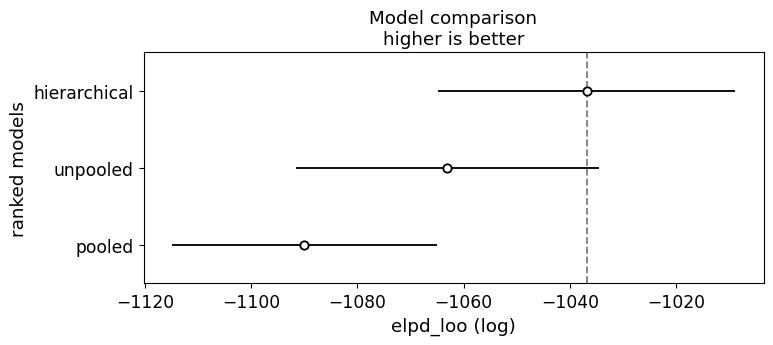

In [ ]:
az.plot_compare(comparison, figsize=(8, 3))

## Adaptive early-stop with `until`

Pass `until=True` and each fit stops as soon as every scalar parameter clears
the convergence target (R-hat <= 1.01, ESS >= 400), with `draws=` as the cap.
The cheap pooled model converges in a few hundred draws while the richer
models keep going -- no compute wasted oversampling the easy ones. (nutpie /
pymc, remote.)

In [ ]:
_idatas_until = cp.map(models, {"draws": 4000, "tune": 1000, "chains": 4}, until=True)
# draws each model kept -- early-stop => fewer than the 4000 cap
{m.name: int(it.posterior.sizes["draw"]) for m, it in zip(models, _idatas_until)}

cp.map: fitting 3 model(s) in parallel ...
cp.map: dashboard: https://justmytwospence--pooled-fc2f78-dev.modal.run
cp.map: [1/3] done
cp.map: [2/3] done
cp.map: [3/3] done


## Forcing a re-fit with `overwrite`

The first `cp.map` cached each fit, so a plain re-run is an instant cache hit
(it prints `all 3 cached`). Pass `overwrite=True` to ignore the cache, refit
every model, and replace the stored results -- note it prints `fitting 3
model(s)` instead.

In [ ]:
# Re-run ignoring the cache: refits all three (not a cache hit).
_idatas_overwrite = cp.map(models, {"draws": 1000, "tune": 1000, "chains": 4}, overwrite=True)

cp.map: fitting 3 model(s) in parallel ...
cp.map: dashboard: https://justmytwospence--pooled-37978e-dev.modal.run
cp.map: [1/3] done
cp.map: [2/3] done
cp.map: [3/3] done


Dashboard: https://justmytwospence--pooled-37978e-dev.modal.run/ <?xml version='1.0' encoding='UTF-8'?>
 <path d="M2.4,2.4H3V3H2.4zM3,2.4H3.6V3H3zM3.6,2.4H4.2V3H3.6zM4.2,2.4H4.8V3H4.2zM4.8,2.4H5.4V3H4.8zM5.4,2.4H6V3H5.4zM6,2.4H6.6V3H6zM7.8,2.4H8.4V3H7.8zM8.4,2.4H9V3H8.4zM9.6,2.4H10.2V3H9.6zM12,2.4H12.6V3H12zM12.6,2.4H13.2V3H12.6zM13.2,2.4H13.8V3H13.2zM13.8,2.4H14.4V3H13.8zM14.4,2.4H15V3H14.4zM15.6,2.4H16.2V3H15.6zM16.2,2.4H16.8V3H16.2zM18,2.4H18.6V3H18zM18.6,2.4H19.2V3H18.6zM19.2,2.4H19.8V3H19.2zM19.8,2.4H20.4V3H19.8zM20.4,2.4H21V3H20.4zM21,2.4H21.6V3H21zM21.6,2.4H22.2V3H21.6zM2.4,3H3V3.6H2.4zM6,3H6.6V3.6H6zM7.8,3H8.4V3.6H7.8zM9,3H9.6V3.6H9zM11.4,3H12V3.6H11.4zM12.6,3H13.2V3.6H12.6zM15.6,3H16.2V3.6H15.6zM18,3H18.6V3.6H18zM21.6,3H22.2V3.6H21.6zM2.4,3.6H3V4.2H2.4zM3.6,3.6H4.2V4.2H3.6zM4.2,3.6H4.8V4.2H4.2zM4.8,3.6H5.4V4.2H4.8zM6,3.6H6.6V4.2H6zM7.2,3.6H7.8V4.2H7.2zM7.8,3.6H8.4V4.2H7.8zM8.4,3.6H9V4.2H8.4zM10.8,3.6H11.4V4.2H10.8zM11.4,3.6H12V4.2H11.4zM12,3.6H12.6V4.2H12zM13.8,3.6H14.4V4.2H13.8zM14.4,3.6H15V4.2H14.4zM15,3.6H15.6V4.2H15zM15.6,3.6H16.2V4.2H15.6zM18,3.6H18.6V4.2H18zM19.2,3.6H19.8V4.2H19.2zM19.8,3.6H20.4V4.2H19.8zM20.4,3.6H21V4.2H20.4zM21.6,3.6H22.2V4.2H21.6zM2.4,4.2H3V4.8H2.4zM3.6,4.2H4.2V4.8H3.6zM4.2,4.2H4.8V4.8H4.2zM4.8,4.2H5.4V4.8H4.8zM6,4.2H6.6V4.8H6zM7.2,4.2H7.8V4.8H7.2zM9,4.2H9.6V4.8H9zM13.2,4.2H13.8V4.8H13.2zM13.8,4.2H14.4V4.8H13.8zM15.6,4.2H16.2V4.8H15.6zM16.2,4.2H16.8V4.8H16.2zM16.8,4.2H17.4V4.8H16.8zM18,4.2H18.6V4.8H18zM19.2,4.2H19.8V4.8H19.2zM19.8,4.2H20.4V4.8H19.8zM20.4,4.2H21V4.8H20.4zM21.6,4.2H22.2V4.8H21.6zM2.4,4.8H3V5.4H2.4zM3.6,4.8H4.2V5.4H3.6zM4.2,4.8H4.8V5.4H4.2zM4.8,4.8H5.4V5.4H4.8zM6,4.8H6.6V5.4H6zM7.2,4.8H7.8V5.4H7.2zM8.4,4.8H9V5.4H8.4zM9,4.8H9.6V5.4H9zM10.8,4.8H11.4V5.4H10.8zM11.4,4.8H12V5.4H11.4zM12,4.8H12.6V5.4H12zM13.2,4.8H13.8V5.4H13.2zM13.8,4.8H14.4V5.4H13.8zM16.2,4.8H16.8V5.4H16.2zM18,4.8H18.6V5.4H18zM19.2,4.8H19.8V5.4H19.2zM19.8,4.8H20.4V5.4H19.8zM20.4,4.8H21V5.4H20.4zM21.6,4.8H22.2V5.4H21.6zM2.4,5.4H3V6H2.4zM6,5.4H6.6V6H6zM7.2,5.4H7.8V6H7.2zM7.8,5.4H8.4V6H7.8zM8.4,5.4H9V6H8.4zM9.6,5.4H10.2V6H9.6zM10.8,5.4H11.4V6H10.8zM12.6,5.4H13.2V6H12.6zM13.2,5.4H13.8V6H13.2zM15,5.4H15.6V6H15zM18,5.4H18.6V6H18zM21.6,5.4H22.2V6H21.6zM2.4,6H3V6.6H2.4zM3,6H3.6V6.6H3zM3.6,6H4.2V6.6H3.6zM4.2,6H4.8V6.6H4.2zM4.8,6H5.4V6.6H4.8zM5.4,6H6V6.6H5.4zM6,6H6.6V6.6H6zM7.2,6H7.8V6.6H7.2zM8.4,6H9V6.6H8.4zM9.6,6H10.2V6.6H9.6zM10.8,6H11.4V6.6H10.8zM12,6H12.6V6.6H12zM13.2,6H13.8V6.6H13.2zM14.4,6H15V6.6H14.4zM15.6,6H16.2V6.6H15.6zM16.8,6H17.4V6.6H16.8zM18,6H18.6V6.6H18zM18.6,6H19.2V6.6H18.6zM19.2,6H19.8V6.6H19.2zM19.8,6H20.4V6.6H19.8zM20.4,6H21V6.6H20.4zM21,6H21.6V6.6H21zM21.6,6H22.2V6.6H21.6zM7.2,6.6H7.8V7.2H7.2zM9,6.6H9.6V7.2H9zM10.8,6.6H11.4V7.2H10.8zM12,6.6H12.6V7.2H12zM13.8,6.6H14.4V7.2H13.8zM14.4,6.6H15V7.2H14.4zM15,6.6H15.6V7.2H15zM15.6,6.6H16.2V7.2H15.6zM2.4,7.2H3V7.8H2.4zM3.6,7.2H4.2V7.8H3.6zM4.2,7.2H4.8V7.8H4.2zM4.8,7.2H5.4V7.8H4.8zM5.4,7.2H6V7.8H5.4zM6,7.2H6.6V7.8H6zM9,7.2H9.6V7.8H9zM10.2,7.2H10.8V7.8H10.2zM10.8,7.2H11.4V7.8H10.8zM12.6,7.2H13.2V7.8H12.6zM13.8,7.2H14.4V7.8H13.8zM15.6,7.2H16.2V7.8H15.6zM16.2,7.2H16.8V7.8H16.2zM16.8,7.2H17.4V7.8H16.8zM18,7.2H18.6V7.8H18zM18.6,7.2H19.2V7.8H18.6zM19.2,7.2H19.8V7.8H19.2zM19.8,7.2H20.4V7.8H19.8zM20.4,7.2H21V7.8H20.4zM2.4,7.8H3V8.4H2.4zM3,7.8H3.6V8.4H3zM3.6,7.8H4.2V8.4H3.6zM4.2,7.8H4.8V8.4H4.2zM4.8,7.8H5.4V8.4H4.8zM5.4,7.8H6V8.4H5.4zM7.8,7.8H8.4V8.4H7.8zM9.6,7.8H10.2V8.4H9.6zM10.2,7.8H10.8V8.4H10.2zM12,7.8H12.6V8.4H12zM12.6,7.8H13.2V8.4H12.6zM13.2,7.8H13.8V8.4H13.2zM13.8,7.8H14.4V8.4H13.8zM14.4,7.8H15V8.4H14.4zM15,7.8H15.6V8.4H15zM15.6,7.8H16.2V8.4H15.6zM16.2,7.8H16.8V8.4H16.2zM18,7.8H18.6V8.4H18zM18.6,7.8H19.2V8.4H18.6zM19.8,7.8H20.4V8.4H19.8zM20.4,7.8H21V8.4H20.4zM21,7.8H21.6V8.4H21zM21.6,7.8H22.2V8.4H21.6zM4.2,8.4H4.8V9H4.2zM4.8,8.4H5.4V9H4.8zM6,8.4H6.6V9H6zM7.8,8.4H8.4V9H7.8zM9,8.4H9.6V9H9zM9.6,8.4H10.2V9H9.6zM10.2,8.4H10.8V9H10.2zM10.8,8.4H11.4V9H10.8zM11.4,8.4H12V9H11.4zM12,8.4H12.6V9H12zM12.6,8.4H13.2V9H12.6zM14.4,8.4H15V9H14.4zM15,8.4H15.6V9H15zM15.6,8.4H16.2V9H15.6

## Cleanup

`cp.map` provisions a project-scoped volume. Delete it when you're done.

In [ ]:
cp.cleanup_volumes()

/Users/spencerboucher/Projects/cloudposterior-map-dashboard/cloudposterior/backends/modal_backend.py:790: AsyncUsageWarning: A blocking Modal interface is being used in an async context.

This may cause performance issues or bugs. Consider rewriting to use Modal's async interfaces:
https://modal.com/docs/guide/async

Suggested rewrite:
  await modal.Volume.objects.delete.aio(volume_name)

Original line:
  modal.Volume.objects.delete(volume_name)
